In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e6/train.csv
/kaggle/input/competitions/playground-series-s6e6/test.csv


In [2]:
train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e6/train.csv")
train_data.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [3]:
test_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e6/test.csv")
test_data.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [4]:
y = train_data["class"]
features = ["u", "g", "r", "i", "z", "redshift", "spectral_type", "galaxy_population"]

X = train_data[features]
X["g - r"] = X["g"] - X["r"]
X["r - i"] = X["r"] - X["i"]
X["u - g"] = X["u"] - X["g"]

X_test = test_data[features]
X_test["g - r"] = X_test["g"] - X_test["r"]
X_test["r - i"] = X_test["r"] - X_test["i"]
X_test["u - g"] = X_test["u"] - X_test["g"]

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size = 0.8, test_size = 0.2, random_state = 42)

/tmp/ipykernel_16/2914358326.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["g - r"] = X["g"] - X["r"]
/tmp/ipykernel_16/2914358326.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["r - i"] = X["r"] - X["i"]
/tmp/ipykernel_16/2914358326.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#

In [5]:
X.isnull().sum()

u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
g - r                0
r - i                0
u - g                0
dtype: int64

In [6]:
object_cols = list(X_train.select_dtypes(include = "object").columns)
print(object_cols)

['spectral_type', 'galaxy_population']


<Axes: xlabel='u', ylabel='Density'>

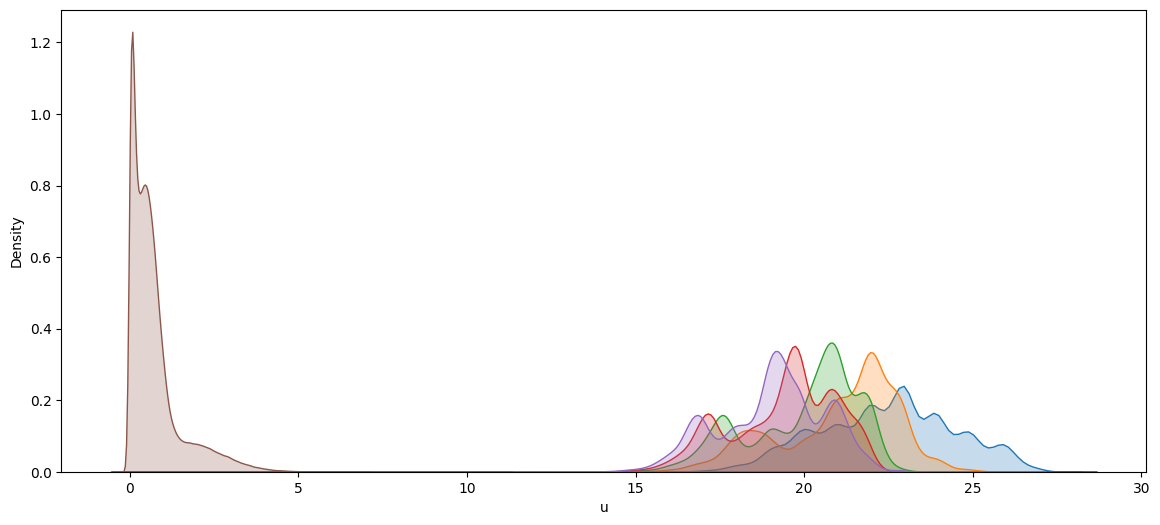

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (14, 6))

sns.kdeplot(data = X["u"], fill = True)
sns.kdeplot(data = X["g"], fill = True)
sns.kdeplot(data = X["r"], fill = True)
sns.kdeplot(data = X["i"], fill = True)
sns.kdeplot(data = X["z"], fill = True)
sns.kdeplot(data = X["redshift"], fill = True)

<Axes: xlabel='spectral_type', ylabel='Count'>

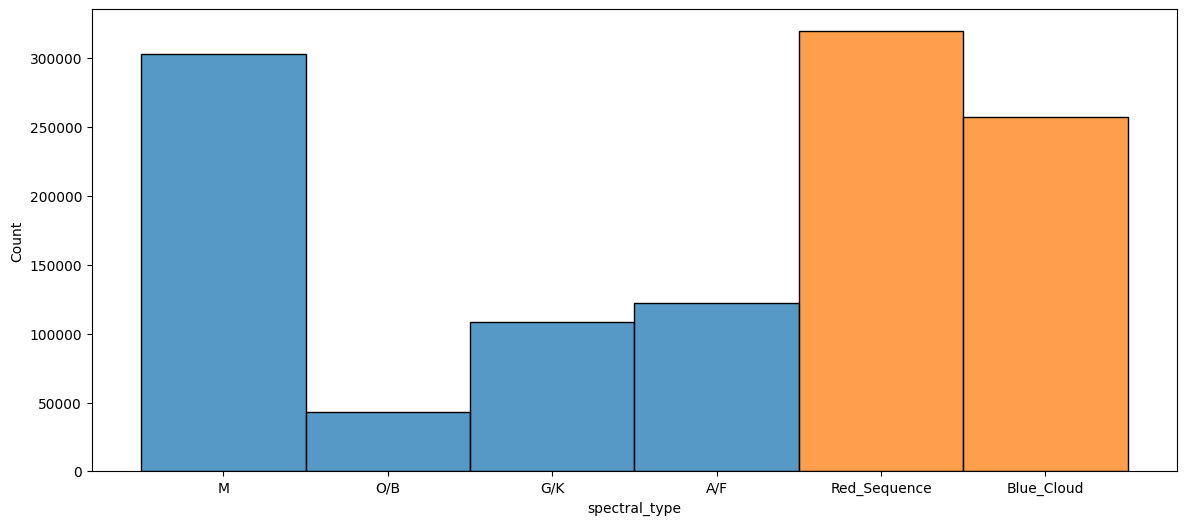

In [8]:
plt.figure(figsize = (14, 6))

sns.histplot(data = X["spectral_type"])
sns.histplot(data = X["galaxy_population"])

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_transformer = Pipeline(steps = [("onehot", OneHotEncoder(handle_unknown = "ignore"))])

preprocessor = ColumnTransformer(transformers = [('cat', categorical_transformer, ["spectral_type", "galaxy_population"])], remainder = "passthrough")

In [10]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score

le = LabelEncoder()
y_train = le.fit_transform(y_train)

model = XGBClassifier(n_estimators = 500, learning_rate = 0.03, max_depth = 6, subsample = 0.8, colsample_bytree = 0.8, min_child_weight = 3, reg_lambda = 1, eval_metric = "mlogloss", random_state = 42)
my_pipeline = Pipeline(steps = [("preprocessor", preprocessor), ("model", model)])
my_pipeline.fit(X_train, y_train)

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
score = cross_val_score(my_pipeline, X_train, y_train, cv = cv, scoring = "accuracy")
print("Accuracy: ", score.mean())

Accuracy:  0.9528164434745893


In [11]:
test = my_pipeline.predict(X_valid)
y_valid = le.transform(y_valid)

print("Accuracy: ", accuracy_score(test, y_valid))

Accuracy:  0.9529488178747727


In [12]:
preds = my_pipeline.predict(X_test)
preds = le.inverse_transform(preds)

output = pd.DataFrame({"id": test_data["id"], "class": preds})
output.to_csv("submission.csv", index = False)

print(output.head())

print("Your submission was successfully saved!")

       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
Your submission was successfully saved!
